# Auslesen der SQLite Metadaten

In [6]:
import sqlite3 as sl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

con = sl.connect('spotify.sqlite')

with con:
    df_master = pd.read_sql_query("SELECT * FROM sqlite_master", con)
    print(f"Anzahl der Tabellen und Sichten: {len(df_master)} \n")
    print("Info über die Tabellen und Sichten:")
    df_master.info()


Anzahl der Tabellen und Sichten: 9 

Info über die Tabellen und Sichten:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      9 non-null      object
 1   name      9 non-null      object
 2   tbl_name  9 non-null      object
 3   rootpage  9 non-null      int64 
 4   sql       9 non-null      object
dtypes: int64(1), object(4)
memory usage: 488.0+ bytes


Da es sich um eine Spotify-Datenbank handelt, sind die wichtigsten Tabellen wahrscheinlich diejenigen, die Informationen über Songs, Alben, Künstler und Playlists enthalten. Um diese Tabellen zu identifizieren, können wir uns die Namen der Tabellen in der Datenbank ansehen. Es gibt die Spalte "name" und die Spalte "tbl_name", die beide die Namen der Tabellen enthalten. Es ist nicht ganz klar, was der Unterschied zwischen diesen beiden Spalten ist, daher sehen wir uns beide an.

In [7]:
print(f"Spalte name: \n{df_master.name} \n")
print(f"Spalte tbl_name: \n{df_master.tbl_name}")


Spalte name: 
0              albums
1             artists
2      audio_features
3              genres
4    r_albums_artists
5     r_albums_tracks
6      r_artist_genre
7      r_track_artist
8              tracks
Name: name, dtype: object 

Spalte tbl_name: 
0              albums
1             artists
2      audio_features
3              genres
4    r_albums_artists
5     r_albums_tracks
6      r_artist_genre
7      r_track_artist
8              tracks
Name: tbl_name, dtype: object


Die Spalte "name" und die Spalte "tbl_name" scheinen in diesem Fall identisch zu sein. Wir können also eine der beiden Spalten verwenden, um die Namen der Tabellen in der Datenbank zu erhalten. Wir filtern das Dataframe, um nur die Einträge mit dem Typ "table" zu erhalten, da wir nur an den Tabellen interessiert sind.

In [8]:
df_tables = df_master[df_master['type'] == 'table']
print(f"Tabellen in der Datenbank: \n{df_tables[['name', 'tbl_name']]}")

Tabellen in der Datenbank: 
               name          tbl_name
0            albums            albums
1           artists           artists
2    audio_features    audio_features
3            genres            genres
4  r_albums_artists  r_albums_artists
5   r_albums_tracks   r_albums_tracks
6    r_artist_genre    r_artist_genre
7    r_track_artist    r_track_artist
8            tracks            tracks


Fangen wir damit an, die Tabelle "tracks" anzusehen, da sie wahrscheinlich Informationen über die Songs enthält.

In [9]:
con.text_factory = lambda b: b.decode(errors='ignore')


def run_sql(query: str) -> pd.DataFrame:
    """Hilfsfunktion fuer kompakte SQL-Auswertungen."""
    return pd.read_sql_query(query, con)



df_tracks = run_sql("""
SELECT *
FROM tracks
""")

print("Info ueber Stichprobe der Tabelle 'tracks' (200k Zeilen):")
df_tracks.info()
print()

print("Deskriptive Statistik (Stichprobe):")
print(df_tracks.describe(include='all'))
print()

print("Erste 5 Eintraege (Stichprobe):")
print(df_tracks.head())


Info ueber Stichprobe der Tabelle 'tracks' (200k Zeilen):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8741672 entries, 0 to 8741671
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                object 
 1   disc_number       int64  
 2   duration          int64  
 3   explicit          int64  
 4   audio_feature_id  object 
 5   name              object 
 6   preview_url       object 
 7   track_number      int64  
 8   popularity        int64  
 9   is_playable       float64
dtypes: float64(1), int64(5), object(4)
memory usage: 666.9+ MB

Deskriptive Statistik (Stichprobe):
                            id   disc_number      duration      explicit  \
count                  8741672  8.741672e+06  8.741672e+06  8.741672e+06   
unique                 8741672           NaN           NaN           NaN   
top     1dizvxctg9dHEyaYTFufVi           NaN           NaN           NaN   
freq                         1           NaN        

Erste Einordnung der Attribute in `tracks`:
- `id`: Eindeutige Track-ID
- `audio_feature_id`: Verknuepfung zu `audio_features`
- `duration`: Track-Dauer in Millisekunden
- `popularity`: Spotify-Popularitaet (erwartet 0-100)
- `explicit`: binarer Marker fuer explizite Inhalte
- `is_playable`: erwarteter binarer Marker (potenziell mit fehlenden Werten)


Als naechstes explorieren wir die restlichen Tabellen ebenfalls effizient: Struktur, Zeilenanzahl und Kernstatistiken (ohne komplette Vollauslese in Pandas).

In [10]:
table_names = run_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")['name'].tolist()

schema_overview = []
for table_name in table_names:
    n_rows = run_sql(f"SELECT COUNT(*) AS n_rows FROM {table_name}").iloc[0, 0]
    n_cols = len(run_sql(f"PRAGMA table_info({table_name})"))
    schema_overview.append({
        'table': table_name,
        'n_rows': int(n_rows),
        'n_cols': int(n_cols)
    })

df_schema_overview = pd.DataFrame(schema_overview).sort_values('n_rows', ascending=False)
print("Tabellenueberblick (nach Zeilen sortiert):")
print(df_schema_overview)


Tabellenueberblick (nach Zeilen sortiert):
              table    n_rows  n_cols
7    r_track_artist  11840402       2
5   r_albums_tracks   9900173       2
8            tracks   8741672      10
2    audio_features   8740043      15
0            albums   4820754       6
1           artists   1066031       4
4  r_albums_artists    921486       2
6    r_artist_genre    487386       2
3            genres      5489       1


In [11]:
print("Schemas aller Tabellen:")
for table_name in table_names:
    print(f"\n[{table_name}]")
    print(run_sql(f"PRAGMA table_info({table_name})")[['cid', 'name', 'type', 'notnull', 'pk']])


Schemas aller Tabellen:

[albums]
   cid          name type  notnull  pk
0    0            id             0   0
1    1          name             0   0
2    2   album_group             0   0
3    3    album_type             0   0
4    4  release_date             0   0
5    5    popularity             0   0

[artists]
   cid        name type  notnull  pk
0    0        name             0   0
1    1          id             0   0
2    2  popularity             0   0
3    3   followers             0   0

[audio_features]
    cid              name type  notnull  pk
0     0                id             0   0
1     1      acousticness             0   0
2     2      analysis_url             0   0
3     3      danceability             0   0
4     4          duration             0   0
5     5            energy             0   0
6     6  instrumentalness             0   0
7     7               key             0   0
8     8          liveness             0   0
9     9          loudness             0

## Datenqualitaet: Missing Values, Duplikate, Wertebereiche

In [12]:
df_tracks_quality = run_sql("""
SELECT
    COUNT(*) AS n,
    SUM(CASE WHEN id IS NULL OR TRIM(id) = '' THEN 1 ELSE 0 END) AS id_missing,
    SUM(CASE WHEN audio_feature_id IS NULL OR TRIM(audio_feature_id) = '' THEN 1 ELSE 0 END) AS audio_feature_id_missing,
    SUM(CASE WHEN name IS NULL OR TRIM(name) = '' THEN 1 ELSE 0 END) AS name_missing,
    SUM(CASE WHEN duration IS NULL THEN 1 ELSE 0 END) AS duration_missing,
    SUM(CASE WHEN popularity IS NULL THEN 1 ELSE 0 END) AS popularity_missing,
    SUM(CASE WHEN explicit IS NULL THEN 1 ELSE 0 END) AS explicit_missing,
    SUM(CASE WHEN is_playable IS NULL THEN 1 ELSE 0 END) AS is_playable_missing,
    SUM(CASE WHEN preview_url IS NULL OR TRIM(preview_url) = '' THEN 1 ELSE 0 END) AS preview_url_missing,
    COUNT(*) - COUNT(DISTINCT id) AS duplicate_track_ids,
    COUNT(*) - COUNT(DISTINCT audio_feature_id) AS duplicate_audio_feature_ids_in_tracks,
    SUM(CASE WHEN popularity < 0 OR popularity > 100 THEN 1 ELSE 0 END) AS popularity_out_of_range,
    SUM(CASE WHEN explicit NOT IN (0, 1) AND explicit IS NOT NULL THEN 1 ELSE 0 END) AS explicit_invalid,
    SUM(CASE WHEN is_playable NOT IN (0, 1) AND is_playable IS NOT NULL THEN 1 ELSE 0 END) AS is_playable_invalid,
    SUM(CASE WHEN duration <= 0 THEN 1 ELSE 0 END) AS duration_non_positive
FROM tracks
""")
print("Qualitaetscheck tracks:")
print(df_tracks_quality.T)


Qualitaetscheck tracks:
                                             0
n                                      8741672
id_missing                                   0
audio_feature_id_missing                   562
name_missing                              3954
duration_missing                             0
popularity_missing                           0
explicit_missing                             0
is_playable_missing                    8327872
preview_url_missing                    2277559
duplicate_track_ids                          0
duplicate_audio_feature_ids_in_tracks     1628
popularity_out_of_range                      0
explicit_invalid                             0
is_playable_invalid                          0
duration_non_positive                        1


In [13]:
df_audio_quality = run_sql("""
SELECT
    COUNT(*) AS n,
    COUNT(*) - COUNT(DISTINCT id) AS duplicate_audio_feature_ids,
    SUM(CASE WHEN acousticness < 0 OR acousticness > 1 THEN 1 ELSE 0 END) AS acousticness_out_of_range,
    SUM(CASE WHEN danceability < 0 OR danceability > 1 THEN 1 ELSE 0 END) AS danceability_out_of_range,
    SUM(CASE WHEN energy < 0 OR energy > 1 THEN 1 ELSE 0 END) AS energy_out_of_range,
    SUM(CASE WHEN instrumentalness < 0 OR instrumentalness > 1 THEN 1 ELSE 0 END) AS instrumentalness_out_of_range,
    SUM(CASE WHEN liveness < 0 OR liveness > 1 THEN 1 ELSE 0 END) AS liveness_out_of_range,
    SUM(CASE WHEN speechiness < 0 OR speechiness > 1 THEN 1 ELSE 0 END) AS speechiness_out_of_range,
    SUM(CASE WHEN valence < 0 OR valence > 1 THEN 1 ELSE 0 END) AS valence_out_of_range,
    SUM(CASE WHEN key < 0 OR key > 11 THEN 1 ELSE 0 END) AS key_out_of_range,
    SUM(CASE WHEN mode NOT IN (0, 1) THEN 1 ELSE 0 END) AS mode_out_of_range,
    SUM(CASE WHEN time_signature < 1 OR time_signature > 7 THEN 1 ELSE 0 END) AS time_signature_out_of_range,
    SUM(CASE WHEN duration <= 0 THEN 1 ELSE 0 END) AS duration_non_positive,
    SUM(CASE WHEN tempo <= 0 THEN 1 ELSE 0 END) AS tempo_non_positive
FROM audio_features
""")
print("Qualitaetscheck audio_features:")
print(df_audio_quality.T)


Qualitaetscheck audio_features:
                                     0
n                              8740043
duplicate_audio_feature_ids          0
acousticness_out_of_range            0
danceability_out_of_range            0
energy_out_of_range                  0
instrumentalness_out_of_range        0
liveness_out_of_range                0
speechiness_out_of_range             0
valence_out_of_range                 0
key_out_of_range                     0
mode_out_of_range                    0
time_signature_out_of_range      34979
duration_non_positive                0
tempo_non_positive               34764


## Join-Qualitaet (orphan checks)

In [14]:
df_orphans = run_sql("""
SELECT
    (SELECT COUNT(*) FROM tracks t LEFT JOIN audio_features af ON t.audio_feature_id = af.id WHERE af.id IS NULL) AS tracks_without_audio_features,
    (SELECT COUNT(*) FROM audio_features af LEFT JOIN tracks t ON af.id = t.audio_feature_id WHERE t.audio_feature_id IS NULL) AS audio_features_without_tracks,
    (SELECT COUNT(*) FROM r_track_artist r LEFT JOIN tracks t ON r.track_id = t.id WHERE t.id IS NULL) AS r_track_artist_orphan_track,
    (SELECT COUNT(*) FROM r_track_artist r LEFT JOIN artists a ON r.artist_id = a.id WHERE a.id IS NULL) AS r_track_artist_orphan_artist,
    (SELECT COUNT(*) FROM r_albums_tracks r LEFT JOIN albums a ON r.album_id = a.id WHERE a.id IS NULL) AS r_albums_tracks_orphan_album,
    (SELECT COUNT(*) FROM r_albums_tracks r LEFT JOIN tracks t ON r.track_id = t.id WHERE t.id IS NULL) AS r_albums_tracks_orphan_track,
    (SELECT COUNT(*) FROM r_albums_artists r LEFT JOIN albums a ON r.album_id = a.id WHERE a.id IS NULL) AS r_albums_artists_orphan_album,
    (SELECT COUNT(*) FROM r_albums_artists r LEFT JOIN artists a ON r.artist_id = a.id WHERE a.id IS NULL) AS r_albums_artists_orphan_artist,
    (SELECT COUNT(*) FROM r_artist_genre r LEFT JOIN artists a ON r.artist_id = a.id WHERE a.id IS NULL) AS r_artist_genre_orphan_artist,
    (SELECT COUNT(*) FROM r_artist_genre r LEFT JOIN genres g ON r.genre_id = g.id WHERE g.id IS NULL) AS r_artist_genre_orphan_genre
""")
print("Orphan-Check der Beziehungen:")
print(df_orphans.T)


Orphan-Check der Beziehungen:
                                  0
tracks_without_audio_features   562
audio_features_without_tracks     0
r_track_artist_orphan_track       0
r_track_artist_orphan_artist      0
r_albums_tracks_orphan_album      0
r_albums_tracks_orphan_track      0
r_albums_artists_orphan_album     0
r_albums_artists_orphan_artist    0
r_artist_genre_orphan_artist      0
r_artist_genre_orphan_genre       0


## Deskriptive Statistiken fuer Kerngroessen

In [15]:
df_tracks_desc = run_sql("""
SELECT
    MIN(duration) AS duration_min,
    MAX(duration) AS duration_max,
    AVG(duration) AS duration_mean,
    MIN(popularity) AS popularity_min,
    MAX(popularity) AS popularity_max,
    AVG(popularity) AS popularity_mean
FROM tracks
""")
print("Tracks - Vollmengen-Statistik:")
print(df_tracks_desc)


Tracks - Vollmengen-Statistik:
   duration_min  duration_max  duration_mean  popularity_min  popularity_max  \
0             0      19672058  236968.738876               0             100   

   popularity_mean  
0         6.118262  


In [16]:
df_quantiles_sample = df_tracks[['duration', 'popularity']].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("Tracks - Quantile (Stichprobe):")
print(df_quantiles_sample)


Tracks - Quantile (Stichprobe):
       duration  popularity
0.01   32946.00         0.0
0.05   86626.00         0.0
0.25  169200.00         0.0
0.50  216160.00         1.0
0.75  273887.00         8.0
0.95  434279.45        30.0
0.99  661600.00        48.0


In [17]:
print("Top-10 Popularitaetswerte (Stichprobe):")
print(df_tracks['popularity'].value_counts(dropna=False).head(10))
print()
print("Verteilung explicit (Stichprobe):")
print(df_tracks['explicit'].value_counts(dropna=False))
print()
print("Verteilung is_playable (Stichprobe):")
print(df_tracks['is_playable'].value_counts(dropna=False))


Top-10 Popularitaetswerte (Stichprobe):
popularity
0    3980551
1     746177
2     484901
3     363835
4     293538
5     246014
6     213189
7     189955
8     169887
9     154126
Name: count, dtype: int64

Verteilung explicit (Stichprobe):
explicit
0    8157738
1     583934
Name: count, dtype: int64

Verteilung is_playable (Stichprobe):
is_playable
NaN    8327872
1.0     362237
0.0      51563
Name: count, dtype: int64


## Visualisierungen: Tracks-Stichprobe

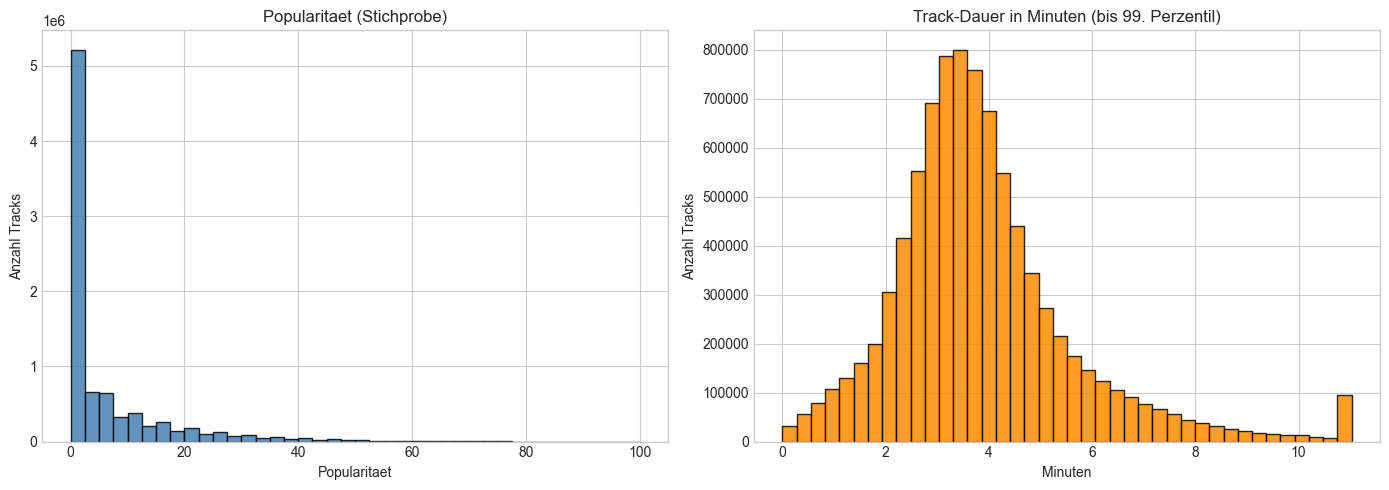

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_tracks['popularity'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Popularitaet (Stichprobe)')
axes[0].set_xlabel('Popularitaet')
axes[0].set_ylabel('Anzahl Tracks')

# Dauer in Minuten mit 99%-Clipping fuer besser lesbare Verteilung.
duration_min = (df_tracks['duration'].dropna() / 60000).clip(upper=(df_tracks['duration'].dropna() / 60000).quantile(0.99))
axes[1].hist(duration_min, bins=40, color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_title('Track-Dauer in Minuten (bis 99. Perzentil)')
axes[1].set_xlabel('Minuten')
axes[1].set_ylabel('Anzahl Tracks')

plt.tight_layout()
plt.show()


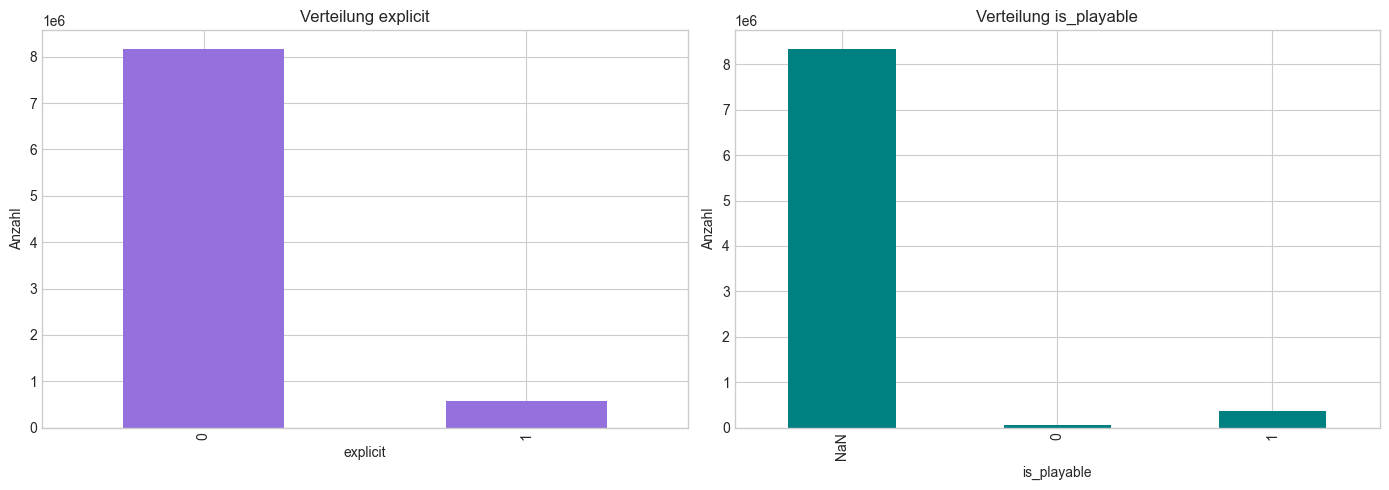

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_tracks['explicit'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Verteilung explicit')
axes[0].set_xlabel('explicit')
axes[0].set_ylabel('Anzahl')

is_playable_counts = df_tracks['is_playable'].fillna(-1).value_counts().sort_index()
is_playable_counts.index = ['NaN' if x == -1 else str(int(x)) for x in is_playable_counts.index]
is_playable_counts.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Verteilung is_playable')
axes[1].set_xlabel('is_playable')
axes[1].set_ylabel('Anzahl')

plt.tight_layout()
plt.show()


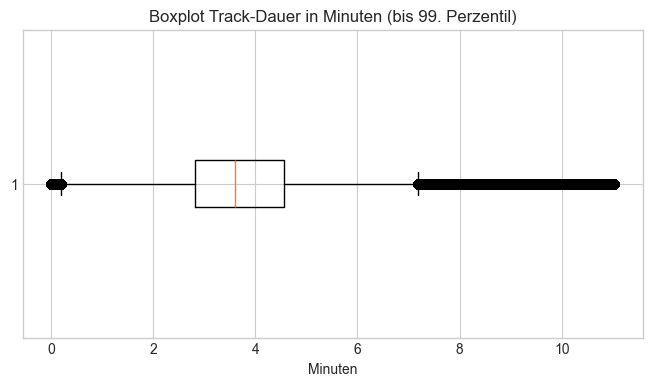

In [20]:
plt.figure(figsize=(8, 4))
plt.boxplot(duration_min, vert=False)
plt.title('Boxplot Track-Dauer in Minuten (bis 99. Perzentil)')
plt.xlabel('Minuten')
plt.show()


## Visualisierung: Missingness-Quote in `tracks`

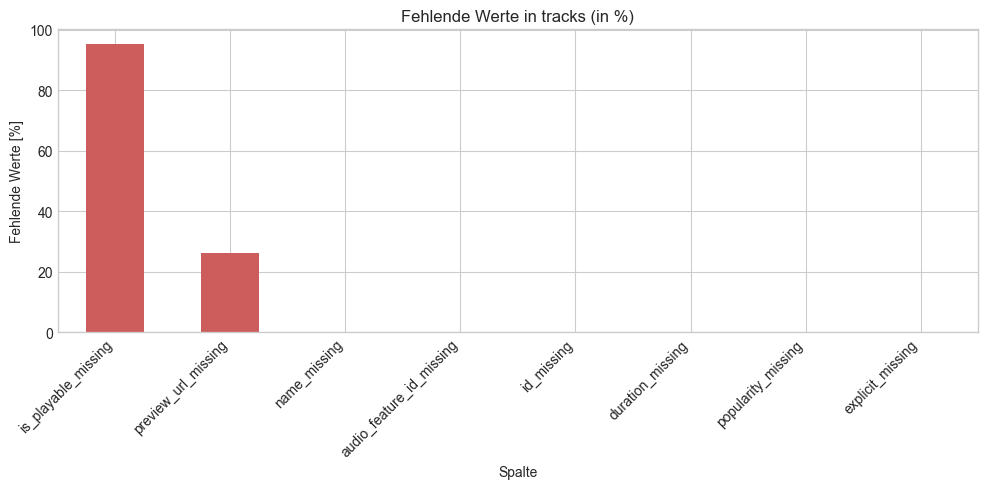

In [21]:
missing_cols = [
    'id_missing',
    'audio_feature_id_missing',
    'name_missing',
    'duration_missing',
    'popularity_missing',
    'explicit_missing',
    'is_playable_missing',
    'preview_url_missing'
]

n_tracks = df_tracks_quality.loc[0, 'n']
missing_pct = (df_tracks_quality.loc[0, missing_cols] / n_tracks * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='bar', color='indianred')
plt.title('Fehlende Werte in tracks (in %)')
plt.ylabel('Fehlende Werte [%]')
plt.xlabel('Spalte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Visualisierungen: Audio-Features + Korrelationen

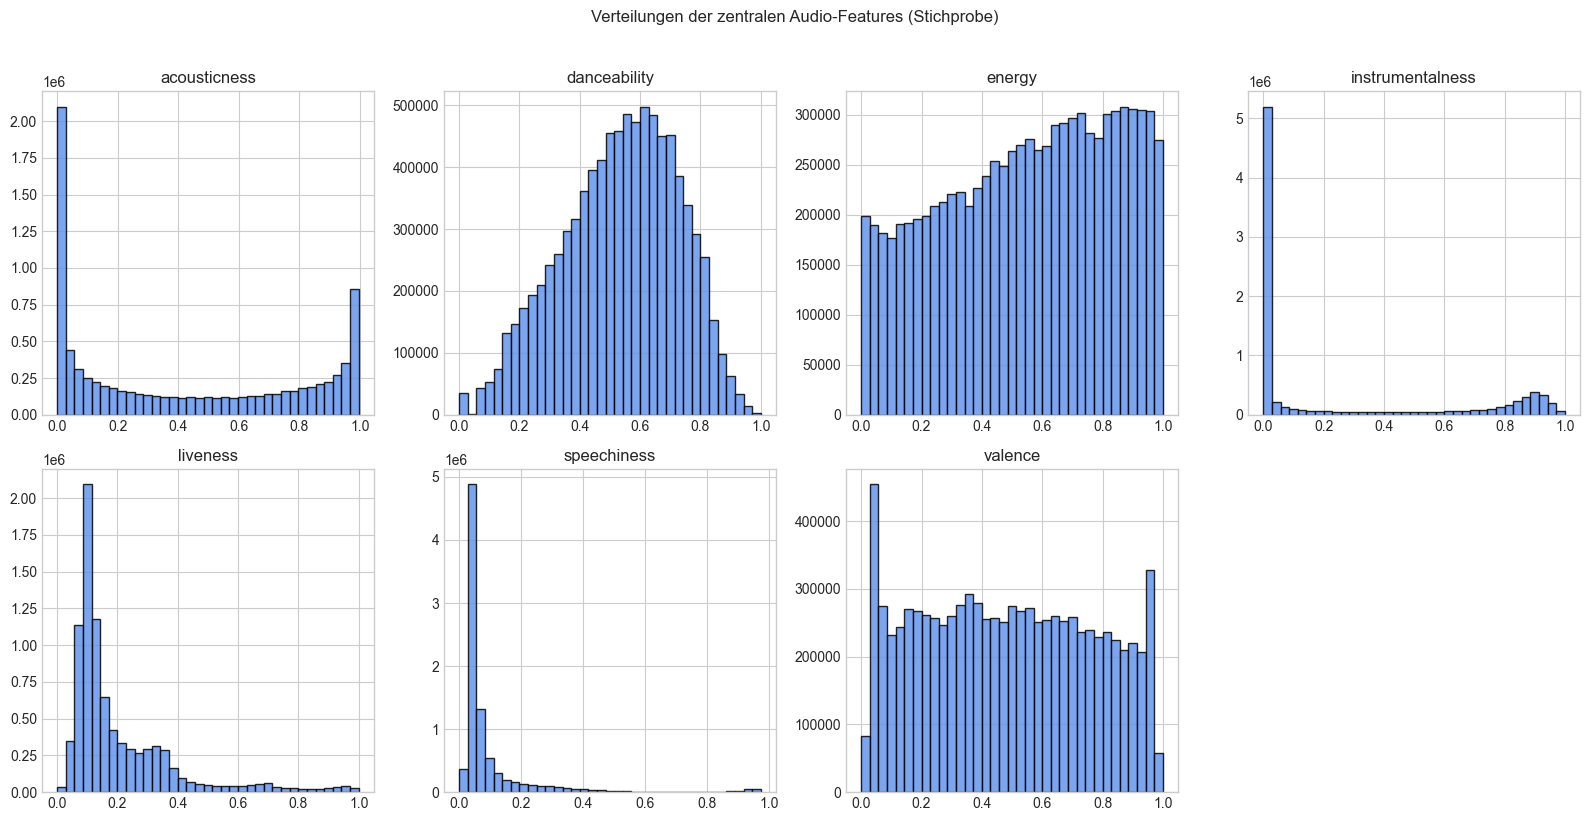

In [22]:
df_track_audio_features = run_sql("""
SELECT
    t.popularity,
    t.duration AS track_duration,
    af.acousticness,
    af.danceability,
    af.energy,
    af.instrumentalness,
    af.liveness,
    af.speechiness,
    af.valence,
    af.loudness,
    af.tempo
FROM tracks t
JOIN audio_features af ON t.audio_feature_id = af.id
""")

feature_cols_01 = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols_01):
    axes[i].hist(df_track_audio_features[col].dropna(), bins=35, color='cornflowerblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(col)

axes[-1].axis('off')
plt.suptitle('Verteilungen der zentralen Audio-Features (Stichprobe)', y=1.02)
plt.tight_layout()
plt.show()


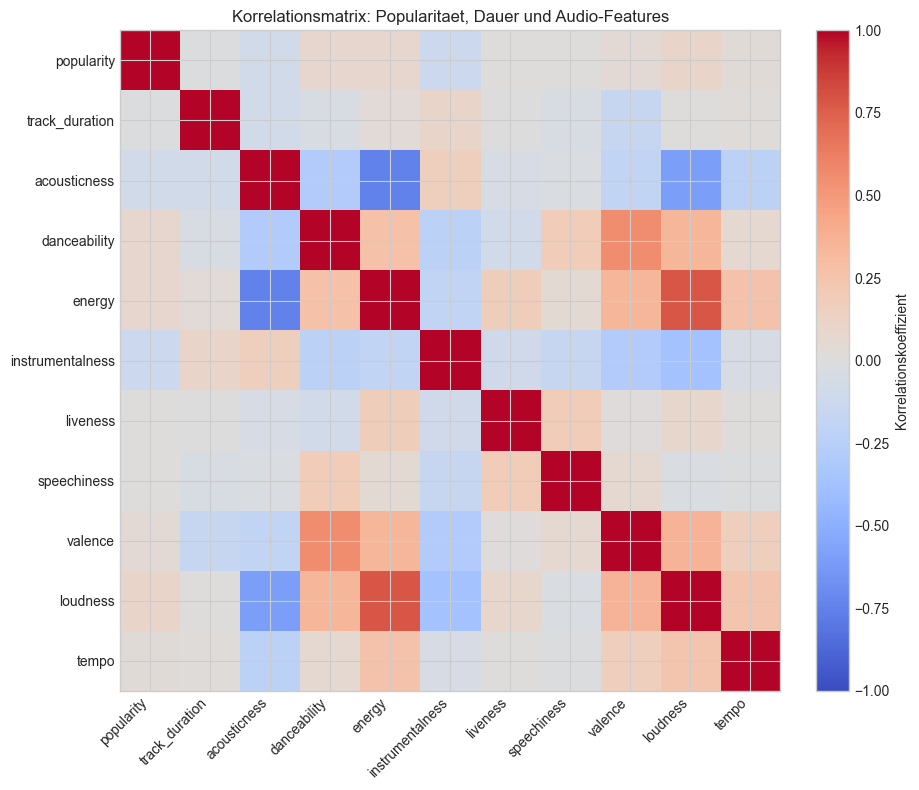

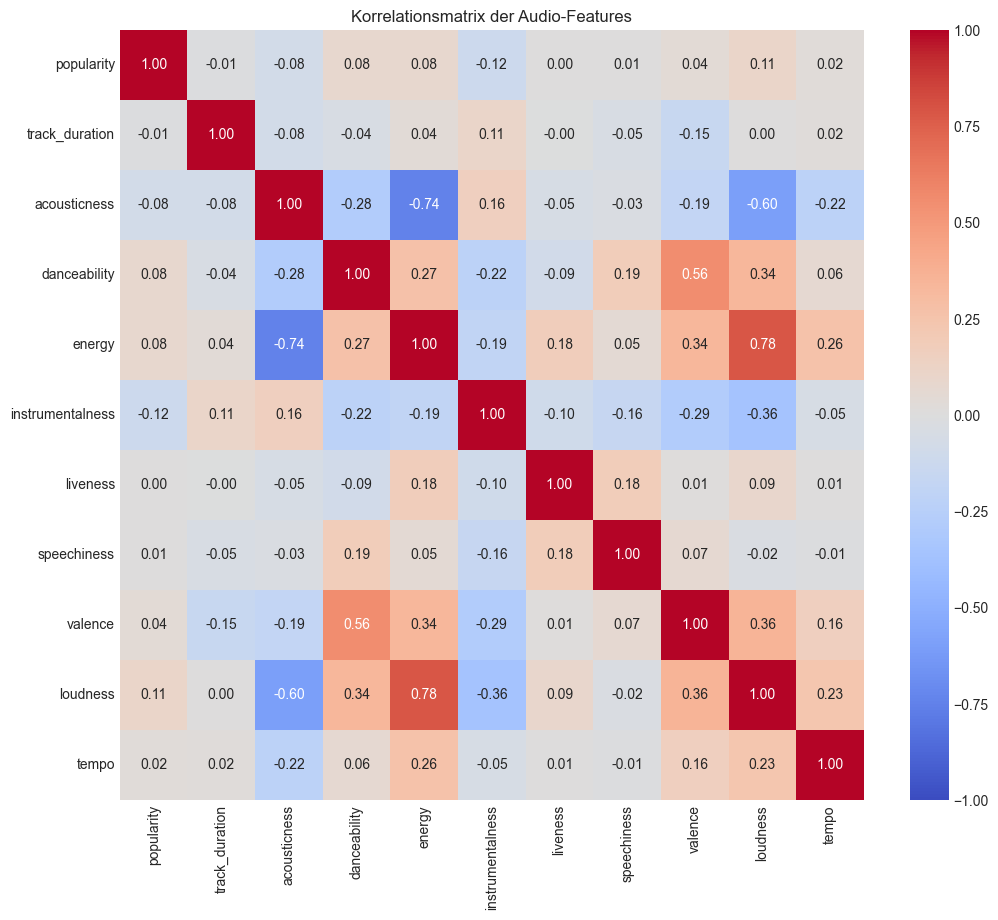

In [23]:
corr_cols = [
    'popularity', 'track_duration', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'speechiness', 'valence', 'loudness', 'tempo'
]

corr_matrix = df_track_audio_features[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label='Korrelationskoeffizient')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Korrelationsmatrix: Popularitaet, Dauer und Audio-Features')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = df_track_audio_features[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korrelationsmatrix der Audio-Features')
plt.show()


## Erste Bereinigungs-Backlog-Kandidaten (aus EDA ableiten)
1. Fehlende und ggf. unbrauchbare Werte in `tracks` (`is_playable`, `preview_url`, evtl. `name`) systematisch behandeln.
2. Referenzielle Integritaet fuer alle `r_`-Tabellen sichern (Orphans entfernen oder sauber markieren).
3. Ueberlange/auffaellige `duration`-Werte als Ausreisserregel definieren (z. B. oberhalb 99. Perzentil pruefen).
4. Doppelte IDs und potenzielle Mehrfachzuordnungen je nach Business-Regel behandeln (beibehalten vs. deduplizieren).
5. Vor Modellierung eine saubere Master-Tabelle erstellen (`tracks` + `audio_features` + Artist/Album/Genre-Mapping).


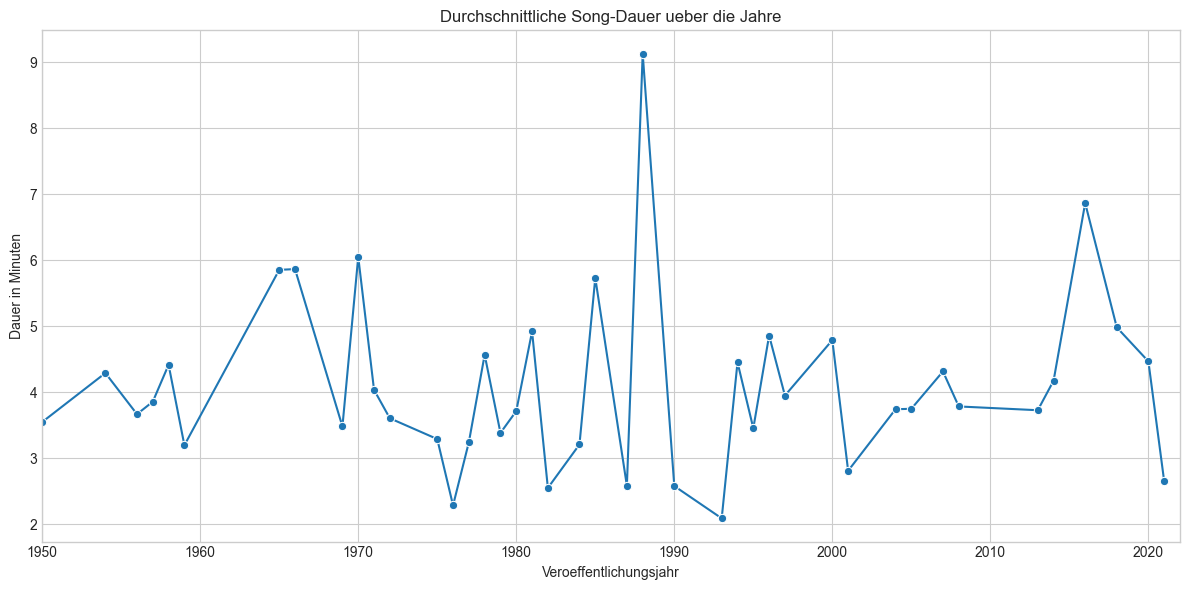

   release_year  duration_min  n_tracks
0          1950      3.549031        43
1          1954      4.291402         9
2          1956      3.668173        30
3          1957      3.857566        39
4          1958      4.416772        10


In [30]:
# Jahresaggregation direkt in SQLite: deutlich speicherschonender als große Pandas-Merges.
df_duration_by_year = run_sql("""
SELECT
    CAST(SUBSTR(a.release_date, 1, 4) AS INTEGER) AS release_year,
    AVG(t.duration) / 60000.0 AS duration_min,
    COUNT(*) AS n_tracks
FROM tracks t
JOIN r_albums_tracks rat ON t.id = rat.track_id
JOIN albums a ON rat.album_id = a.id
WHERE a.release_date IS NOT NULL
  AND LENGTH(TRIM(a.release_date)) >= 4
  AND t.duration IS NOT NULL
  AND CAST(SUBSTR(a.release_date, 1, 4) AS INTEGER) BETWEEN 1950 AND 2022
GROUP BY CAST(SUBSTR(a.release_date, 1, 4) AS INTEGER)
ORDER BY release_year
""")

assert not df_duration_by_year.empty, "Die Jahresaggregation ist leer; SQL-oder Datumslogik pruefen."

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_duration_by_year, x='release_year', y='duration_min', marker='o')
plt.title('Durchschnittliche Song-Dauer über die Jahre')
plt.xlabel('Veroeffentlichungsjahr')
plt.ylabel('Dauer in Minuten')
plt.xlim(1950, 2022)
plt.tight_layout()
plt.show()

print(df_duration_by_year.head())
